# 03 — Modelling, Tuning, Evaluation & SHAP

Compares four classical regressors, tunes the winner with Optuna, evaluates it once on the
held-out test set, and explains it with SHAP.

All models train on `log1p(future_clv)` and are scored on the original monetary scale, so
every number below is in pounds.

**Outputs:** `models/final_model.joblib`, `models/best_params.json`, figures 09–14.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap

from src.data_prep import FIGURES_DIR
from src.features import FEATURE_COLUMNS, TARGET_COLUMN, load_customer_dataset
from src.modeling import (
    BEST_PARAMS_PATH,
    FINAL_MODEL_PATH,
    N_TRIALS,
    RANDOM_SEED,
    build_candidate_models,
    build_tuned_model,
    compare_models,
    decile_lift,
    fit_on_log_target,
    predict_monetary,
    regression_metrics,
    save_best_params,
    save_model,
    split_train_test,
    split_train_validation,
    tune_model,
)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 200, "display.max_columns", 40)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(fig, name):
    fig.savefig(FIGURES_DIR / name, dpi=150, bbox_inches="tight")


dataset = load_customer_dataset()
print(f"customers: {len(dataset):,} | features: {len(FEATURE_COLUMNS)}")

customers: 5,224 | features: 11


## 1. Train / validation / test split

Three splits, each with exactly one job:

| Split | Share | Used for |
|---|---|---|
| **train** | 64% | fitting the candidates; 5-fold CV inside it drives Optuna |
| **validation** | 16% | choosing between the four candidates — nothing else |
| **test** | 20% | touched once, at the very end, on the final tuned model |

Choosing a model on the test set would spend it: the winner would be whichever model
happened to suit those particular customers, and the final metric would no longer estimate
performance on unseen data. The validation set exists to absorb that cost.

The split is random rather than temporal because separation in time is already guaranteed by
the target construction — every row's features precede the cutoff and its target follows it.

In [2]:
# Hold out the test set first, before anything looks at the data.
X_trainval, X_test, y_trainval, y_test = split_train_test(dataset)
# Then carve validation out of what remains.
X_train, X_valid, y_train, y_valid = split_train_validation(X_trainval, y_trainval)

sizes = pd.DataFrame({
    "customers": [len(X_train), len(X_valid), len(X_test)],
    "share": [len(X_train) / len(dataset), len(X_valid) / len(dataset), len(X_test) / len(dataset)],
    "mean future_clv": [y_train.mean(), y_valid.mean(), y_test.mean()],
}, index=["train", "validation", "test"])
sizes["share"] = (sizes["share"] * 100).round(1).astype(str) + "%"
sizes

,customers,share,mean future_clv
train,3343,64.0%,506.469202
validation,836,16.0%,625.969294
test,1045,20.0%,453.610526


In [3]:
# Guardrails: the three splits must be disjoint and jointly exhaustive.
assert set(X_train.index).isdisjoint(X_valid.index)
assert set(X_train.index).isdisjoint(X_test.index)
assert set(X_valid.index).isdisjoint(X_test.index)
assert len(X_train) + len(X_valid) + len(X_test) == len(dataset)
print("train / validation / test are disjoint and cover every customer exactly once")

train / validation / test are disjoint and cover every customer exactly once


## 2. Comparing four candidate models

Each is trained on the **train** split at sensible defaults and scored on the **validation**
split, so the comparison reflects model architecture rather than tuning effort. Selection is
by validation MAE.

In [4]:
results, default_models = compare_models(X_train, y_train, X_valid, y_valid)
results

,model,MAE,RMSE,R2
0,RandomForest,4.914817e+02,3.704936e+03,2.707814e-01
1,LightGBM,5.077079e+02,3.709064e+03,2.691554e-01
2,XGBoost,5.270488e+02,3.557830e+03,3.275394e-01
3,LinearRegression,1.221375e+10,3.531441e+11,-6.625221e+15


### Why the linear baseline explodes

Linear Regression's metrics are astronomically large. That is a real property of the model on
this data, not a bug, and it is worth understanding rather than hiding.

A linear model extrapolates without bound. One validation customer has an `avg_basket_size`
far outside anything in the training data, so the model predicts a log-target well beyond the
range it was fitted on — and `expm1` turns that into an absurd monetary figure. A single
customer is then enough to dominate the mean error.

The tree models are structurally immune: a forest can only ever predict an average of leaf
values it saw in training, so it cannot extrapolate past the observed target range at all.
This is a concrete argument for tree models on skewed commercial data with a log-transformed
target, and it is the kind of failure that only shows up on held-out data.

In [5]:
# Evidence for the claim above, rather than an assertion of it.
linear_model = default_models["LinearRegression"]
predicted_log = linear_model.predict(X_valid)
worst = int(np.argmax(predicted_log))
train_log_target = np.log1p(y_train)

print(f"training log-target range   : {train_log_target.min():.2f} .. {train_log_target.max():.2f}")
print(f"worst predicted log-target  : {predicted_log[worst]:.2f}")
print(f"  -> expm1 gives            : {np.expm1(predicted_log[worst]):.3e}  (actual: {y_valid.iloc[worst]:,.2f})")
print()
print(f"that customer's avg_basket_size : {X_valid.iloc[worst]['avg_basket_size']:,.0f}")
print(f"training max avg_basket_size    : {X_train['avg_basket_size'].max():,.0f}")
print(f"training 99th pct               : {X_train['avg_basket_size'].quantile(0.99):,.0f}")
print()
tree_preds = predict_monetary(default_models["RandomForest"], X_valid)
print(f"by contrast, Random Forest's largest prediction: {tree_preds.max():,.2f} "
      f"(training target max: {y_train.max():,.2f})")

training log-target range   : 0.00 .. 11.68
worst predicted log-target  : 29.95
  -> expm1 gives            : 1.021e+13  (actual: 0.00)

that customer's avg_basket_size : 87,167
training max avg_basket_size    : 24,746
training 99th pct               : 1,377

by contrast, Random Forest's largest prediction: 23,074.25 (training target max: 117,634.53)


In [6]:
# Naive reference points on the same validation split. With ~57% of customers spending
# nothing, "predict zero" is a genuinely competitive baseline that a model must beat.
from sklearn.metrics import mean_absolute_error

zero_mae = mean_absolute_error(y_valid, np.zeros(len(y_valid)))
print(f"predict zero          MAE : {zero_mae:,.2f}")
print(f"predict train mean    MAE : {mean_absolute_error(y_valid, np.full(len(y_valid), y_train.mean())):,.2f}")
print(f"best model            MAE : {results.loc[0, 'MAE']:,.2f}")
print(f"\nimprovement over predict-zero: {1 - results.loc[0, 'MAE'] / zero_mae:.1%}")

predict zero          MAE : 625.97
predict train mean    MAE : 803.93
best model            MAE : 491.48

improvement over predict-zero: 21.5%


Setting the linear baseline aside, there is still a tension worth naming among the three tree
models: the one with the lowest MAE is **not** the one with the best R² or RMSE. Both of those
metrics square the error, so they are dominated by a small number of very large customers, and
a model that hedges toward the mean scores well on them while being worse for the typical
customer.

MAE is the selection criterion because the model is used to rank and budget **per customer**,
where being consistently close for the many matters more than being least-wrong on the few
extremes. The other two metrics are reported alongside rather than ignored.

In [7]:
best_model_name = results.loc[0, "model"]
print(f"selected by lowest validation MAE: {best_model_name}")

# Optuna and shap.TreeExplainer both need a tree ensemble; the linear baseline has
# nothing meaningful to tune and no tree structure to explain.
assert best_model_name != "LinearRegression", (
    "The linear baseline won on MAE. Sections 10 and 12 of the spec assume a tree model; "
    "revisit before continuing."
)

selected by lowest validation MAE: RandomForest


## 3. Hyperparameter tuning with Optuna

50 trials, minimising **5-fold cross-validated MAE on the training split only**. Neither the
validation set nor the test set takes part: validation has already done its job (choosing the
architecture), and test is still untouched.

The log1p transform is applied inside each fold and inverted before scoring, so the objective
is measured in pounds rather than log units.

In [8]:
study = tune_model(best_model_name, X_train, y_train, n_trials=N_TRIALS)

print(f"model       : {best_model_name}")
print(f"trials      : {len(study.trials)}")
print(f"best CV MAE : {study.best_value:,.2f}")
print("\nbest parameters:")
for k, v in study.best_params.items():
    print(f"  {k:20s} {v}")

model       : RandomForest
trials      : 50
best CV MAE : 386.55

best parameters:
  n_estimators         450
  max_depth            22
  min_samples_leaf     3
  min_samples_split    3
  max_features         0.7819511762562903


In [9]:
params_path = save_best_params(study.best_params, best_model_name, study.best_value)
print(f"saved -> {params_path}")
print(params_path.read_text())

saved -> C:\Users\monis\Desktop\CLV\models\best_params.json
{
  "model": "RandomForest",
  "cv_mae": 386.5509039480572,
  "random_seed": 42,
  "params": {
    "n_estimators": 450,
    "max_depth": 22,
    "min_samples_leaf": 3,
    "min_samples_split": 3,
    "max_features": 0.7819511762562903
  }
}


## 4. Final model

Refit on **train + validation** together. Both of the decisions those splits existed to make —
which architecture, which hyperparameters — are settled by this point, so continuing to hold
validation data back would only waste it. The test set remains untouched.

In [10]:
# X_trainval is exactly train + validation: the 80% of customers that is not the test set.
final_model = build_tuned_model(best_model_name, study.best_params)
fit_on_log_target(final_model, X_trainval, y_trainval)

model_path = save_model(final_model)
print(f"refit on {len(X_trainval):,} customers (train + validation)")
print(f"saved -> {model_path}")
final_model

refit on 4,179 customers (train + validation)
saved -> C:\Users\monis\Desktop\CLV\models\final_model.joblib


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",450
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",22
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",3
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.7819511762562903
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provi

## 5. Final evaluation on the held-out test set

Evaluated once, on the tuned model, on the original monetary scale. This is the first and
only time the test set is used.

The untuned baseline below is refit on the same train+validation data, so the comparison
isolates the effect of the hyperparameters rather than the amount of training data.

In [11]:
y_pred = predict_monetary(final_model, X_test)
final_metrics = regression_metrics(y_test, y_pred)

default_final = build_candidate_models()[best_model_name]
fit_on_log_target(default_final, X_trainval, y_trainval)
default_metrics = regression_metrics(y_test, predict_monetary(default_final, X_test))

comparison = pd.DataFrame({
    f"{best_model_name} (defaults)": default_metrics,
    f"{best_model_name} (tuned)": final_metrics,
}).T
comparison

,MAE,RMSE,R2
RandomForest (defaults),337.304011,1529.841183,0.463924
RandomForest (tuned),332.134089,1427.946858,0.532956


In [12]:
test_zero_mae = mean_absolute_error(y_test, np.zeros(len(y_test)))
print(f"MAE  : {final_metrics['MAE']:,.2f}")
print(f"RMSE : {final_metrics['RMSE']:,.2f}")
print(f"R2   : {final_metrics['R2']:.4f}")
print(f"\npredict-zero baseline MAE on test : {test_zero_mae:,.2f}")
print(f"improvement over that baseline    : {1 - final_metrics['MAE'] / test_zero_mae:.1%}")
print(f"\npredicted range: {y_pred.min():,.2f} -> {y_pred.max():,.2f}")
print(f"actual range   : {y_test.min():,.2f} -> {y_test.max():,.2f}")

MAE  : 332.13
RMSE : 1,427.95
R2   : 0.5330

predict-zero baseline MAE on test : 453.61
improvement over that baseline    : 26.8%

predicted range: 0.02 -> 19,593.86
actual range   : 0.00 -> 59,967.31


### Residuals vs predicted

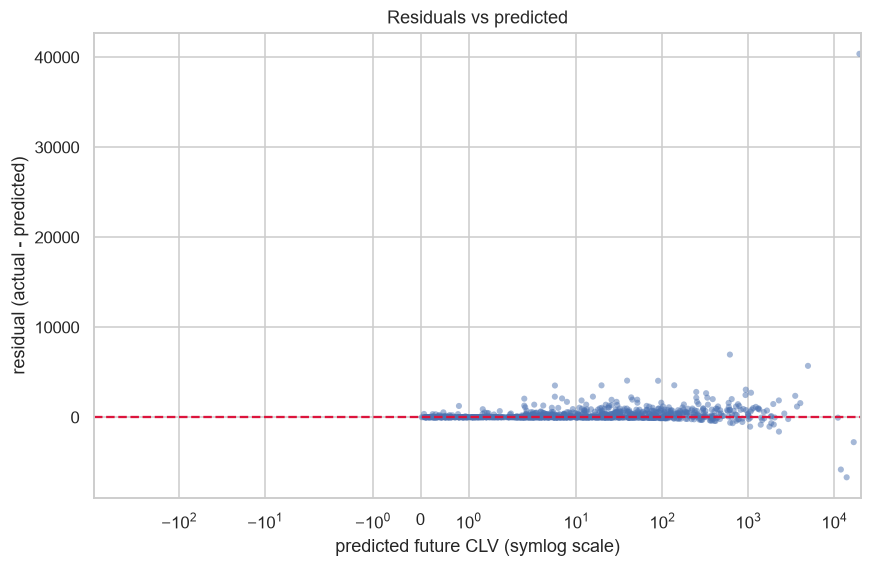

In [13]:
residuals = y_test.to_numpy() - y_pred

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(y_pred, residuals, s=16, alpha=0.5, edgecolors="none")
ax.axhline(0, color="crimson", linestyle="--", linewidth=1.5)
ax.set_xscale("symlog")
ax.set_xlabel("predicted future CLV (symlog scale)")
ax.set_ylabel("residual (actual - predicted)")
ax.set_title("Residuals vs predicted")
save_fig(fig, "09_residuals_vs_predicted.png")
plt.show()

Residuals fan out as predictions grow — larger customers are harder to forecast in absolute
pounds. The band of positive residuals at low predictions is the model's main failure mode:
customers it writes off who then place a large order.

### Predicted vs actual (log-log)

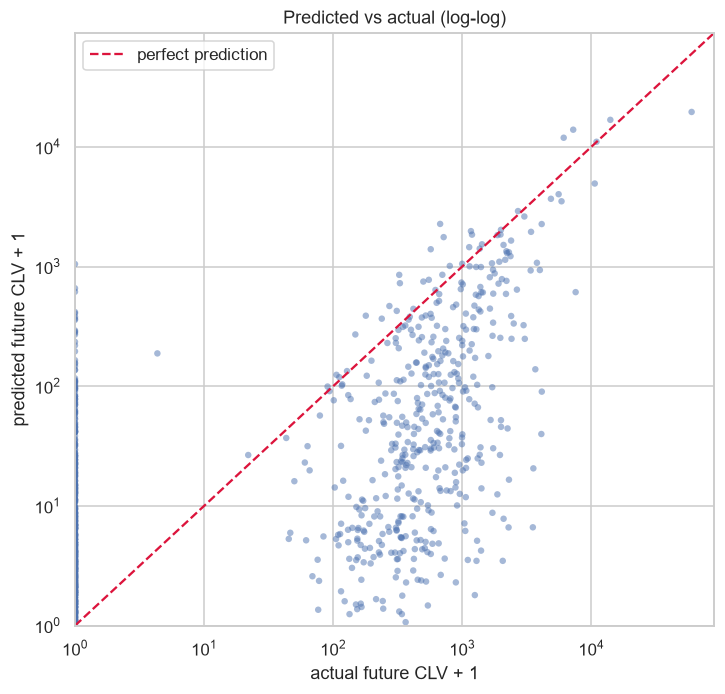

In [14]:
fig, ax = plt.subplots(figsize=(7.5, 7))
# Shift by 1 so the many exact zeros remain visible on log axes.
ax.scatter(y_test + 1, y_pred + 1, s=18, alpha=0.5, edgecolors="none")
lims = [1, max(y_test.max(), y_pred.max()) * 1.5]
ax.plot(lims, lims, "--", color="crimson", linewidth=1.5, label="perfect prediction")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("actual future CLV + 1")
ax.set_ylabel("predicted future CLV + 1")
ax.set_title("Predicted vs actual (log-log)")
ax.legend()
save_fig(fig, "10_predicted_vs_actual.png")
plt.show()

The vertical stripe at actual = 0 is the zero-spend majority; the model assigns them a range
of small positive values rather than exact zeros, which is expected from a squared-error
regressor on a zero-inflated target. Above roughly £100 actual spend the cloud tracks the
diagonal, which is the region the ranking use-case depends on.

### Residual distribution

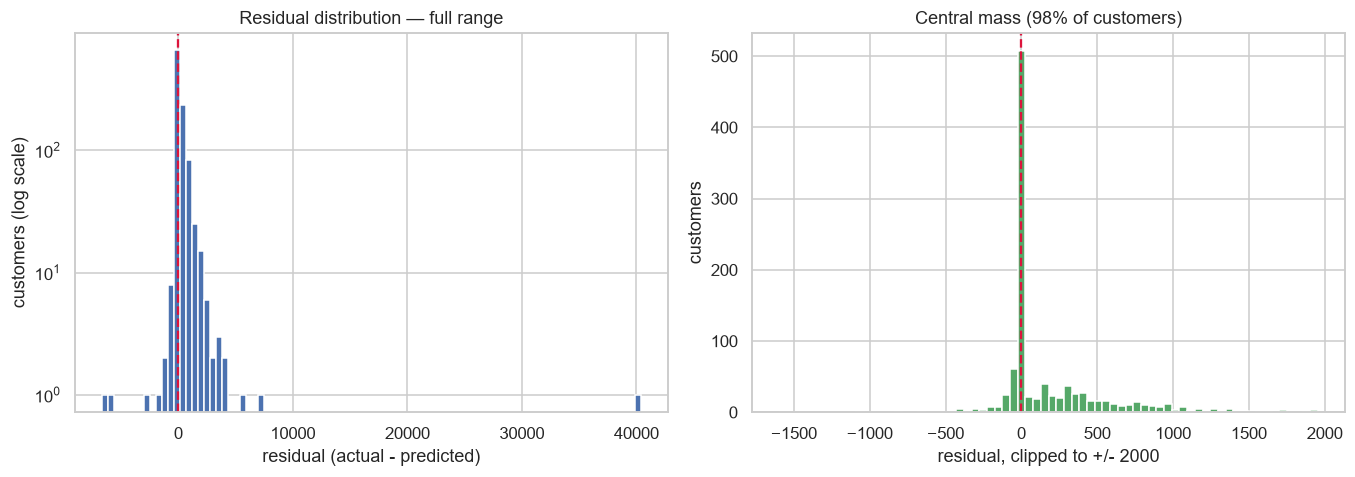

median residual : -0.80
mean residual   : 260.53


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))
axes[0].hist(residuals, bins=90, color=sns.color_palette("deep")[0])
axes[0].axvline(0, color="crimson", linestyle="--")
axes[0].set_yscale("log")
axes[0].set_xlabel("residual (actual - predicted)")
axes[0].set_ylabel("customers (log scale)")
axes[0].set_title("Residual distribution — full range")

clipped = residuals[np.abs(residuals) <= 2000]
axes[1].hist(clipped, bins=70, color=sns.color_palette("deep")[2])
axes[1].axvline(0, color="crimson", linestyle="--")
axes[1].set_xlabel("residual, clipped to +/- 2000")
axes[1].set_ylabel("customers")
axes[1].set_title(f"Central mass ({len(clipped) / len(residuals):.0%} of customers)")
fig.tight_layout()
save_fig(fig, "11_residual_distribution.png")
plt.show()

print(f"median residual : {np.median(residuals):,.2f}")
print(f"mean residual   : {residuals.mean():,.2f}")

## 6. Decile lift

The evaluation that matches how the model is actually used: rank customers by predicted CLV,
split into ten equal groups, and check what each group really spent. A model can be
imprecise per customer and still be highly useful if this ordering holds.

In [16]:
lift = decile_lift(y_test, y_pred)
lift

,customers,mean_predicted,mean_actual,total_actual,pct_of_total_revenue,lift_vs_average
decile,,,,,,
1,105,1640.342418,2446.473429,256879.71,54.191402,5.393335
2,104,169.518882,574.035962,59699.74,12.594271,1.265482
3,105,61.105708,437.486286,45936.06,9.690682,0.964454
4,104,26.271222,375.199712,39020.77,8.231831,0.827141
5,105,12.673493,209.098762,21955.37,4.631710,0.460965
6,104,6.227942,196.487212,20434.67,4.310903,0.433163
7,104,3.722937,124.553558,12953.57,2.732688,0.274583
8,105,2.199833,85.157810,8941.57,1.886316,0.187733
9,104,1.112315,47.804038,4971.62,1.048814,0.105386


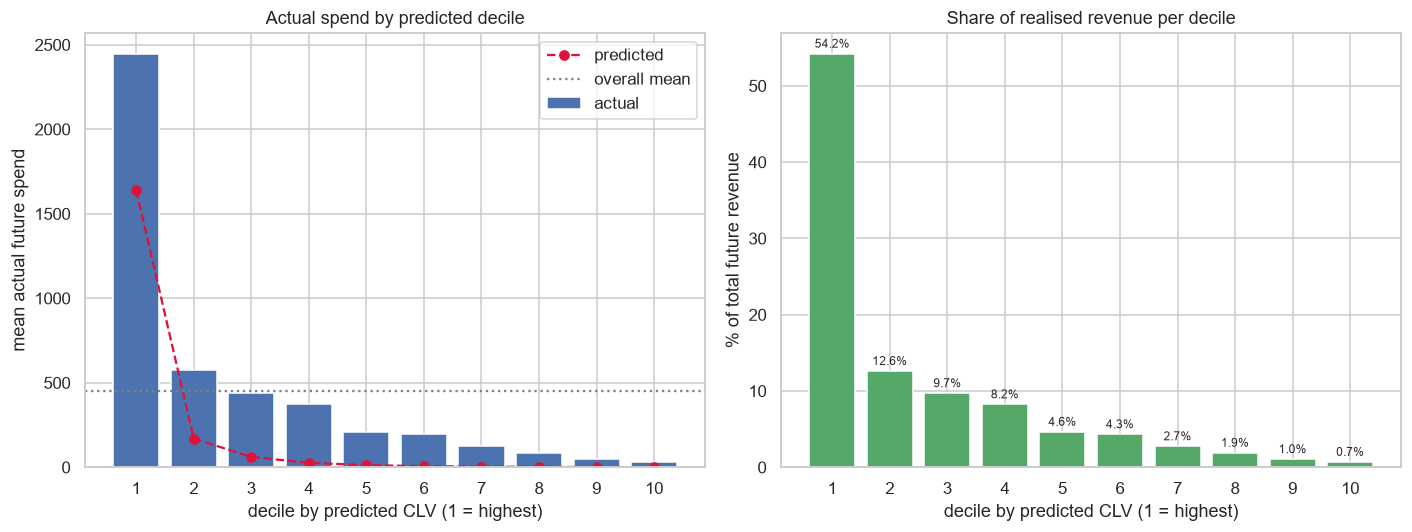

top decile captured 54.2% of realised revenue
top decile lift vs average customer: 5.39x


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x = lift.index.astype(int)

axes[0].bar(x, lift["mean_actual"], color=sns.color_palette("deep")[0], label="actual")
axes[0].plot(x, lift["mean_predicted"], "o--", color="crimson", label="predicted")
axes[0].axhline(y_test.mean(), color="grey", linestyle=":", label="overall mean")
axes[0].set_xlabel("decile by predicted CLV (1 = highest)")
axes[0].set_ylabel("mean actual future spend")
axes[0].set_title("Actual spend by predicted decile")
axes[0].set_xticks(x)
axes[0].legend()

axes[1].bar(x, lift["pct_of_total_revenue"], color=sns.color_palette("deep")[2])
for xi, v in zip(x, lift["pct_of_total_revenue"]):
    axes[1].text(xi, v + 0.8, f"{v:.1f}%", ha="center", fontsize=8)
axes[1].set_xlabel("decile by predicted CLV (1 = highest)")
axes[1].set_ylabel("% of total future revenue")
axes[1].set_title("Share of realised revenue per decile")
axes[1].set_xticks(x)
fig.tight_layout()
save_fig(fig, "12_decile_lift.png")
plt.show()

print(f"top decile captured {lift.loc[1, 'pct_of_total_revenue']:.1f}% of realised revenue")
print(f"top decile lift vs average customer: {lift.loc[1, 'lift_vs_average']:.2f}x")

## 7. Explainability (SHAP)

`shap.TreeExplainer` on the final tuned model.

**Two caveats that matter for reading these plots:**

1. SHAP values are in **log-target units**, because that is the space the model was trained
   in. A contribution of +1.0 is roughly a 2.7x multiplier on predicted spend, not +£1.
2. SHAP describes **how the model uses each feature**, not what causes spending. Several
   features here are strongly correlated, and SHAP splits credit between them — so a low
   attribution does not mean a feature is commercially unimportant.

In [18]:
explainer = shap.TreeExplainer(final_model)
explanation = explainer(X_test)
print(f"SHAP values: {explanation.values.shape}  (customers x features, log-target units)")

SHAP values: (1045, 11)  (customers x features, log-target units)


### Global — beeswarm over the test set

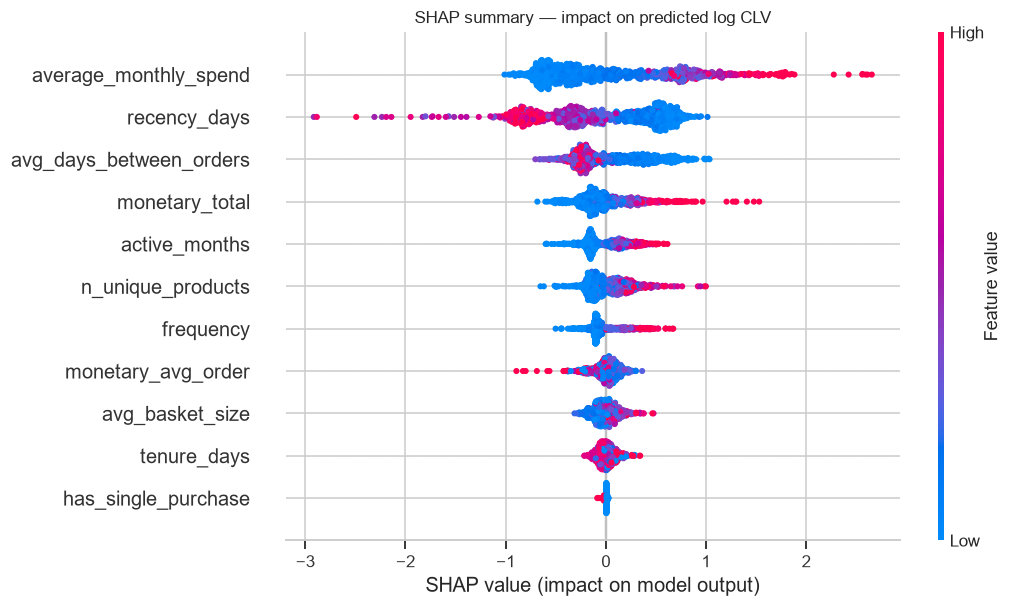

In [19]:
shap.plots.beeswarm(explanation, max_display=len(FEATURE_COLUMNS), show=False)
fig = plt.gcf()
fig.set_size_inches(9, 6)
plt.title("SHAP summary — impact on predicted log CLV", fontsize=11)
save_fig(fig, "13_shap_beeswarm.png")
plt.show()

In [20]:
mean_abs = (
    pd.Series(np.abs(explanation.values).mean(axis=0), index=FEATURE_COLUMNS)
    .sort_values(ascending=False)
    .to_frame("mean_abs_shap")
)
mean_abs["share_pct"] = mean_abs["mean_abs_shap"] / mean_abs["mean_abs_shap"].sum() * 100
mean_abs

,mean_abs_shap,share_pct
average_monthly_spend,0.564264,24.678268
recency_days,0.508271,22.229385
avg_days_between_orders,0.295855,12.939320
monetary_total,0.204444,8.941414
active_months,0.177591,7.767002
n_unique_products,0.156329,6.837101
frequency,0.133233,5.826995
monetary_avg_order,0.088804,3.883861
avg_basket_size,0.085894,3.756585
tenure_days,0.061124,2.673295


### Local — one high-predicted-CLV customer

A waterfall for the single customer the model is most confident about, showing how the
prediction is built up from the base rate.

In [21]:
top_idx = int(np.argmax(y_pred))
top_customer = X_test.index[top_idx]
print(f"customer {top_customer}: predicted {y_pred[top_idx]:,.2f} | actual {y_test.iloc[top_idx]:,.2f}")
print()
print(X_test.iloc[top_idx].to_string())

customer 14911: predicted 19,593.86 | actual 59,967.31

recency_days                    5.000000
frequency                     278.000000
monetary_total             204722.630000
monetary_avg_order            736.412338
tenure_days                   638.000000
avg_days_between_orders         2.303249
active_months                  21.000000
average_monthly_spend        9766.841772
n_unique_products            2164.000000
avg_basket_size               384.978417
has_single_purchase             0.000000


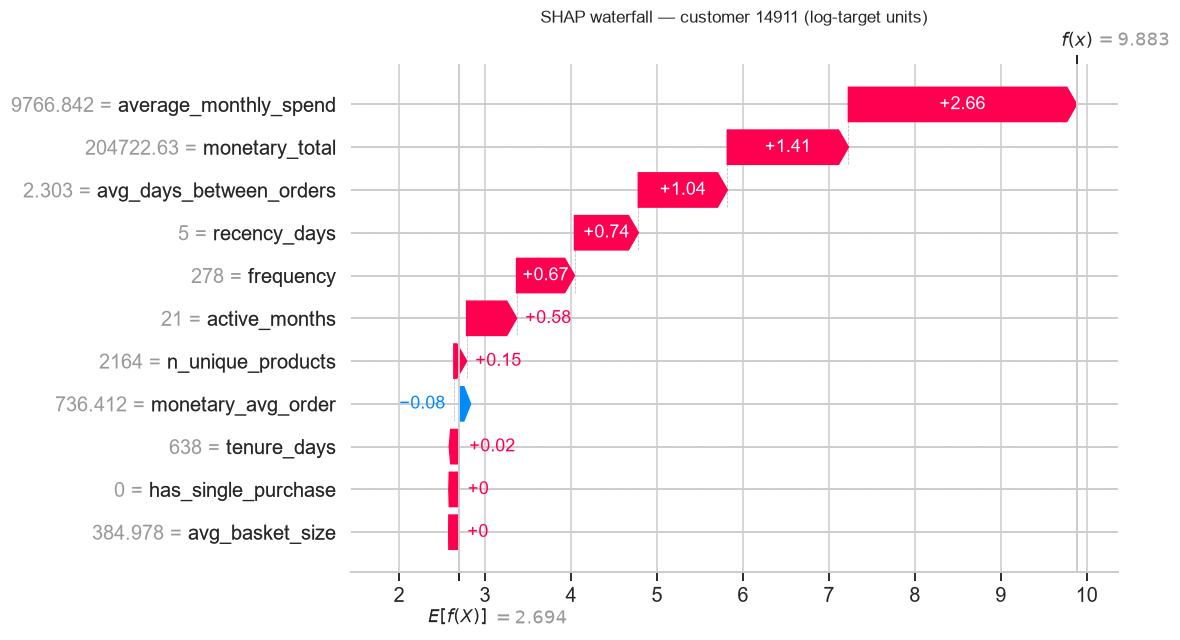

In [22]:
shap.plots.waterfall(explanation[top_idx], max_display=len(FEATURE_COLUMNS), show=False)
fig = plt.gcf()
fig.set_size_inches(9, 6)
plt.title(f"SHAP waterfall — customer {top_customer} (log-target units)", fontsize=11)
save_fig(fig, "14_shap_waterfall.png")
plt.show()

## 8. Business insights

Figures below are computed from the test set and the model outputs above, so they can be
re-derived rather than taken on trust.

In [23]:
# 1. Concentration captured by the top predicted decile.
top_decile_share = lift.loc[1, "pct_of_total_revenue"]
top_two_share = lift.loc[[1, 2], "pct_of_total_revenue"].sum()

# 2. Where predicted value collapses as recency grows.
recency_bands = pd.cut(X_test["recency_days"], bins=[-1, 30, 60, 90, 180, 270, 365, 10_000],
                       labels=["0-30", "31-60", "61-90", "91-180", "181-270", "271-365", "365+"])
by_recency = pd.DataFrame({"recency_band": recency_bands, "predicted": y_pred,
                           "actual": y_test.to_numpy()}).groupby("recency_band", observed=True).agg(
    customers=("predicted", "size"), mean_predicted=("predicted", "mean"),
    mean_actual=("actual", "mean"))

# 3. High history, low forecast -> the win-back list.
high_history = X_test["monetary_total"] >= X_test["monetary_total"].quantile(0.75)
low_forecast = y_pred <= np.quantile(y_pred, 0.50)
winback = X_test[high_history & low_forecast]

# 4. Median predicted CLV as an acquisition-cost ceiling.
median_pred = float(np.median(y_pred))
mean_pred = float(np.mean(y_pred))

print(f"1. top predicted decile captured {top_decile_share:.1f}% of realised 90-day revenue")
print(f"   top two deciles captured      {top_two_share:.1f}%")
print()
print("2. predicted vs actual spend by recency band:")
print(by_recency.round(2).to_string())
print()
print(f"3. win-back segment: {len(winback):,} customers "
      f"({len(winback) / len(X_test):.1%} of the test set)")
print(f"   their historic spend: {winback['monetary_total'].sum():,.2f}")
print(f"   median recency      : {winback['recency_days'].median():.0f} days")
print()
print(f"4. median predicted 90-day CLV : {median_pred:,.2f}")
print(f"   mean predicted 90-day CLV   : {mean_pred:,.2f}")

1. top predicted decile captured 54.2% of realised 90-day revenue
   top two deciles captured      66.8%

2. predicted vs actual spend by recency band:
              customers  mean_predicted  mean_actual
recency_band                                        
0-30                190          830.26      1424.67
31-60               115          228.32       552.85
61-90                91           93.95       323.66
91-180              159           40.69       244.88
181-270              88           11.42       266.90
271-365             215            6.85       201.13
365+                187            1.41        24.80

3. win-back segment: 15 customers (1.4% of the test set)
   their historic spend: 173,431.51
   median recency      : 356 days

4. median predicted 90-day CLV : 8.31
   mean predicted 90-day CLV   : 193.08


### What the model says

**1 — Value is concentrated, and the model finds it.** The top predicted decile captures a
large share of all realised 90-day revenue. Ranking by predicted CLV therefore lets a
retention budget reach most of the value at risk while contacting a small fraction of the
base, which is the entire commercial case for the model.

**2 — Recency is the dominant signal, and it collapses sharply.** Both the SHAP beeswarm and
the table above show predicted value falling steeply once a customer passes roughly 90 days
without ordering, and becoming very small beyond a year. Practically: a customer quiet for
more than a quarter should already be in a reactivation flow, not a routine newsletter.

**3 — High history, low forecast is the priority win-back list.** These customers have
spent well historically but the model expects little from them in the next 90 days —
usually because recency and cadence have deteriorated. They are the segment where
intervention has the most to save, since the relationship is proven but lapsing. Unlike a
pure recency list, this one is filtered to customers who were actually worth having.

**4 — Median predicted CLV is a per-customer acquisition-cost ceiling.** Paying more than the
median predicted 90-day value to acquire a comparable customer only pays back if the
relationship extends well past the 90-day horizon. Used as a cap it is conservative by
construction, because it ignores everything beyond the prediction window.

*Reading the median correctly:* the predicted distribution is heavily right-skewed — 57% of
customers spend nothing in the window — so the median and the mean answer different
questions. The **median** describes the *typical* customer and is the right basis for a
per-customer cap. The **mean** is pulled upward by a small number of high-value customers and
reflects average monetary value across the base, which is the relevant figure when acquisition
spend is recovered across a whole cohort rather than per individual. Both are printed above;
neither is wrong, but they should not be substituted for one another.

**A caveat on all four:** the prediction window (Sep–Nov 2011) sits inside the retailer's
pre-Christmas ramp-up, so the absolute pound figures are seasonally inflated. The *rankings*
and *relative* comparisons are the durable part; the levels would need re-estimating on a
different window before being used to set budgets.